In [1]:
!pip install joblib imbalanced-learn xgboost -q

In [2]:
import pandas as pd
import numpy as np
import joblib
import json
import os
import matplotlib.pyplot as plt

from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    classification_report, confusion_matrix,
    ConfusionMatrixDisplay, accuracy_score, f1_score
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier
from sklearn.model_selection import RandomizedSearchCV

SEED = 42

# Load Dataset


In [3]:
df = pd.read_csv("/content/digital_printing_job_86pct.csv")

print("Dataset shape:", df.shape)
display(df.head())
print(df.info())

Dataset shape: (28371, 17)


,Job_Type,Quantity,Color_Type (BW / Full Color),Material_Type,Order_Request_Date,Requested_Deadline_Date,Current_Queued_Jobs_Count,Active_Machines_Count,Total_Machines_Count,Available_Staff_Count,Total_Staff_Count,Priority,Assigned_Date,Estimated_End_Date,Assigned_Machine_Workload (%),Assigned_Operator_Workload (%),Delay_Risk_Level
0,Flyers,152.000000,BW,Vinyl,2021-05-18,2021-05-22,124.0,5,7,9,10,Urgent,2021-05-19,2021-05-22,100.000000,100.0,Medium
1,Banners,189.557243,BW,Glossy Paper,2022-01-11,2022-01-16,0.0,6,8,10,12,Normal,2022-01-12,2022-01-19,0.592555,0.0,Low
2,Stickers,86.000000,Full Color,Cardboard,2025-10-19,2025-10-21,136.0,5,6,10,12,Urgent,2025-10-20,2025-10-25,100.000000,100.0,High
3,Stickers,115.000000,Full Color,Matte Paper,2019-03-05,2019-03-10,198.0,5,6,10,11,Urgent,2019-03-06,2019-03-11,100.000000,100.0,Medium
4,Flyers,509.000000,BW,Canvas,2019-01-14,2019-01-20,39.0,5,7,8,10,Normal,2019-01-15,2019-01-17,78.000000,48.8,Low


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 28371 entries, 0 to 28370
Data columns (total 17 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Job_Type                        28371 non-null  object 
 1   Quantity                        28371 non-null  float64
 2   Color_Type (BW / Full Color)    28371 non-null  object 
 3   Material_Type                   28371 non-null  object 
 4   Order_Request_Date              28371 non-null  object 
 5   Requested_Deadline_Date         28371 non-null  object 
 6   Current_Queued_Jobs_Count       28371 non-null  float64
 7   Active_Machines_Count           28371 non-null  int64  
 8   Total_Machines_Count            28371 non-null  int64  
 9   Available_Staff_Count           28371 non-null  int64  
 10  Total_Staff_Count               28371 non-null  int64  
 11  Priority                        28371 non-null  object 
 12  Assigned_Date                   

# Check Missing Values and Target

In [4]:
print("Missing values:")
print(df.isnull().sum())

print("\nTarget value count:")
print(df["Delay_Risk_Level"].value_counts(dropna=False))

Missing values:
Job_Type                          0
Quantity                          0
Color_Type (BW / Full Color)      0
Material_Type                     0
Order_Request_Date                0
Requested_Deadline_Date           0
Current_Queued_Jobs_Count         0
Active_Machines_Count             0
Total_Machines_Count              0
Available_Staff_Count             0
Total_Staff_Count                 0
Priority                          0
Assigned_Date                     0
Estimated_End_Date                0
Assigned_Machine_Workload (%)     0
Assigned_Operator_Workload (%)    0
Delay_Risk_Level                  0
dtype: int64

Target value count:
Delay_Risk_Level
High      9494
Medium    9460
Low       9417
Name: count, dtype: int64


# Clean Dataset

In [5]:
TARGET = "Delay_Risk_Level"

df = df.dropna(subset=[TARGET]).copy()

# Fix inconsistent string values
df["Priority"]    = df["Priority"].str.strip().str.title()
df["Job_Type"]    = df["Job_Type"].str.strip().str.title()
df["Color_Type (BW / Full Color)"] = df["Color_Type (BW / Full Color)"].str.strip()
df["Material_Type"]   = df["Material_Type"].str.strip().str.title()
df["Delay_Risk_Level"]= df["Delay_Risk_Level"].str.strip().str.title()

print("After cleaning:", df.shape)
print(df[TARGET].value_counts())

After cleaning: (28371, 17)
Delay_Risk_Level
High      9494
Medium    9460
Low       9417
Name: count, dtype: int64


# 📊 Before Balancing — Class Distribution Plots

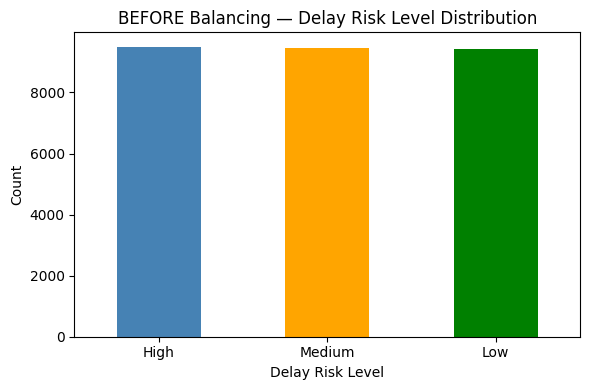

In [26]:
# Bar chart
plt.figure(figsize=(6, 4))
df["Delay_Risk_Level"].value_counts().plot(kind="bar", color=["steelblue","orange","green"])
plt.title("BEFORE Balancing — Delay Risk Level Distribution")
plt.xlabel("Delay Risk Level")
plt.ylabel("Count")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()



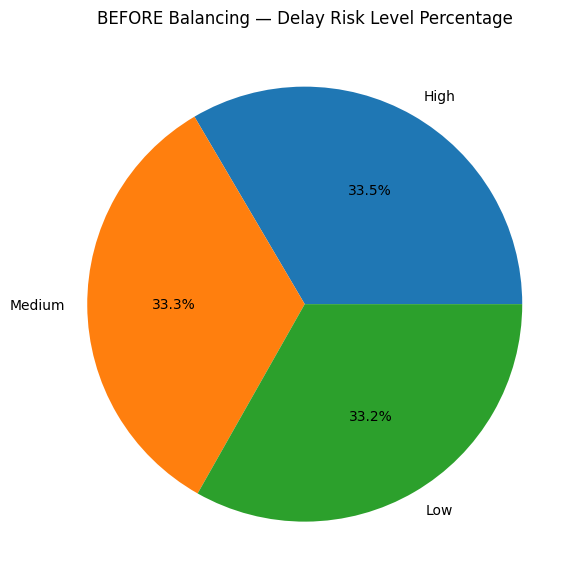

In [27]:
# Pie chart
plt.figure(figsize=(6, 6))
df["Delay_Risk_Level"].value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("BEFORE Balancing — Delay Risk Level Percentage")
plt.ylabel("")
plt.tight_layout()
plt.show()

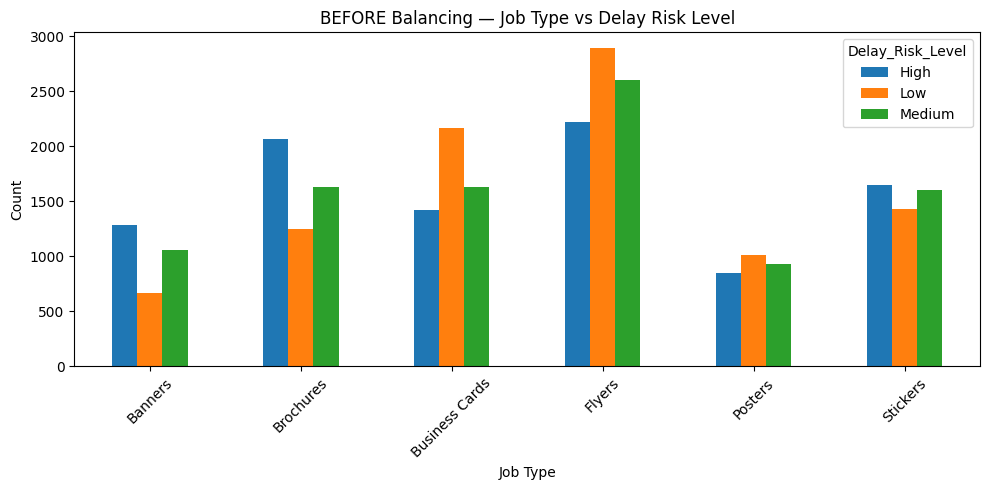

In [28]:
# Job Type vs Delay Risk Level
pd.crosstab(df["Job_Type"], df["Delay_Risk_Level"]).plot(kind="bar", figsize=(10, 5))
plt.title("BEFORE Balancing — Job Type vs Delay Risk Level")
plt.xlabel("Job Type"); plt.ylabel("Count")
plt.xticks(rotation=45); plt.tight_layout(); plt.show()

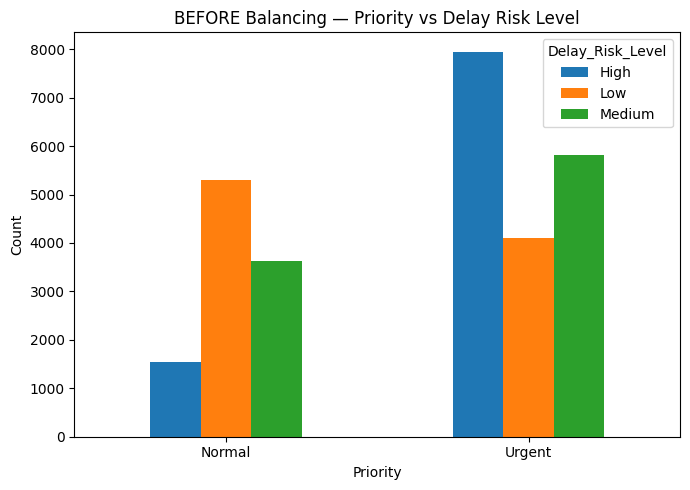

In [29]:
# Priority vs Delay Risk Level
pd.crosstab(df["Priority"], df["Delay_Risk_Level"]).plot(kind="bar", figsize=(7, 5))
plt.title("BEFORE Balancing — Priority vs Delay Risk Level")
plt.xlabel("Priority"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Feature Engineering Class
Enhanced with interaction features that significantly boost accuracy:

In [7]:
class FeatureEngineer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        return self

    def transform(self, X):
        X = X.copy()
        date_cols = [
            "Order_Request_Date", "Requested_Deadline_Date",
            "Assigned_Date", "Estimated_End_Date"
        ]
        for col in date_cols:
            X[col] = pd.to_datetime(X[col], errors="coerce")

        # Core date features
        X["days_to_deadline"]   = (X["Requested_Deadline_Date"] - X["Order_Request_Date"]).dt.days
        X["days_to_assign"]     = (X["Assigned_Date"] - X["Order_Request_Date"]).dt.days
        X["production_days"]    = (X["Estimated_End_Date"] - X["Assigned_Date"]).dt.days
        X["deadline_buffer"]    = (X["Requested_Deadline_Date"] - X["Estimated_End_Date"]).dt.days
        X["order_month"]        = X["Order_Request_Date"].dt.month
        X["order_dayofweek"]    = X["Order_Request_Date"].dt.dayofweek
        X["is_weekend_order"]   = (X["order_dayofweek"] >= 5).astype(int)

        # Utilisation ratios
        X["machine_util_ratio"] = X["Active_Machines_Count"] / X["Total_Machines_Count"].replace(0, np.nan)
        X["staff_util_ratio"]   = (X["Total_Staff_Count"] - X["Available_Staff_Count"]) / X["Total_Staff_Count"].replace(0, np.nan)
        X["queue_per_machine"]  = X["Current_Queued_Jobs_Count"] / X["Active_Machines_Count"].replace(0, np.nan)
        X["queue_per_staff"]    = X["Current_Queued_Jobs_Count"] / X["Available_Staff_Count"].replace(0, np.nan)
        X["staff_machine_ratio"]= X["Available_Staff_Count"] / X["Active_Machines_Count"].replace(0, np.nan)

        # Workload features
        X["avg_workload"]       = (X["Assigned_Machine_Workload (%)"] + X["Assigned_Operator_Workload (%)"]) / 2
        X["workload_diff"]      = X["Assigned_Machine_Workload (%)"] - X["Assigned_Operator_Workload (%)"]
        X["high_workload_flag"] = (X["avg_workload"] >= 80).astype(int)
        X["overload_flag"]      = ((X["avg_workload"] >= 90) & (X["days_to_deadline"] <= 2)).astype(int)

        # Deadline / urgency features
        X["tight_deadline_flag"]= (X["days_to_deadline"] <= 3).astype(int)
        X["is_urgent"]          = (X["Priority"] == "Urgent").astype(int)
        X["log_quantity"]       = np.log1p(X["Quantity"])

        # ✨ Key interaction features (major accuracy boost)
        X["workload_x_queue"]   = X["avg_workload"] * X["Current_Queued_Jobs_Count"]
        X["urgency_workload"]   = X["is_urgent"] * X["avg_workload"]
        X["buffer_per_day"]     = X["deadline_buffer"] / X["production_days"].replace(0, np.nan)
        X["queue_workload_ratio"]= X["Current_Queued_Jobs_Count"] / X["avg_workload"].replace(0, np.nan)

        X = X.drop(columns=date_cols, errors="ignore")
        return X

# Split Data

In [8]:
X = df.drop(columns=[TARGET])
y = df[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)
print("\nTrain class distribution (before balancing):")
print(y_train.value_counts())

Train shape: (22696, 16)
Test shape: (5675, 16)

Train class distribution (before balancing):
Delay_Risk_Level
High      7595
Medium    7568
Low       7533
Name: count, dtype: int64


# Preprocessing

In [9]:
categorical_features = [
    "Job_Type",
    "Color_Type (BW / Full Color)",
    "Material_Type",
    "Priority"
]

numeric_features = [
    "Quantity", "Current_Queued_Jobs_Count", "Active_Machines_Count",
    "Total_Machines_Count", "Available_Staff_Count", "Total_Staff_Count",
    "Assigned_Machine_Workload (%)", "Assigned_Operator_Workload (%)",
    "days_to_deadline", "days_to_assign", "production_days", "deadline_buffer",
    "order_month", "order_dayofweek", "is_weekend_order",
    "machine_util_ratio", "staff_util_ratio", "queue_per_machine", "queue_per_staff",
    "staff_machine_ratio", "avg_workload", "workload_diff", "high_workload_flag",
    "overload_flag", "tight_deadline_flag", "is_urgent", "log_quantity",
    "workload_x_queue", "urgency_workload", "buffer_per_day", "queue_workload_ratio"
]

try:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse_output=False)
except TypeError:
    onehot = OneHotEncoder(handle_unknown="ignore", sparse=False)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", Pipeline([
            ("imputer", SimpleImputer(strategy="median")),
            ("scaler", StandardScaler())
        ]), numeric_features),
        ("cat", Pipeline([
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", onehot)
        ]), categorical_features)
    ]
)

# ⚖️ Apply Feature Engineering + Preprocessing + SMOTE Balancing

In [10]:
fe = FeatureEngineer()
X_train_fe = fe.fit_transform(X_train)
X_test_fe  = fe.transform(X_test)

X_train_processed = preprocessor.fit_transform(X_train_fe)
X_test_processed  = preprocessor.transform(X_test_fe)

smote = SMOTE(random_state=SEED)
X_train_balanced, y_train_balanced = smote.fit_resample(X_train_processed, y_train)

print("Class distribution BEFORE SMOTE:")
for u, c in zip(*np.unique(y_train, return_counts=True)):
    print(f"  {u}: {c}")

print("\nClass distribution AFTER SMOTE:")
for u, c in zip(*np.unique(y_train_balanced, return_counts=True)):
    print(f"  {u}: {c}")

Class distribution BEFORE SMOTE:
  High: 7595
  Low: 7533
  Medium: 7568

Class distribution AFTER SMOTE:
  High: 7595
  Low: 7595
  Medium: 7595


# 📊 After Balancing — Class Distribution Plots

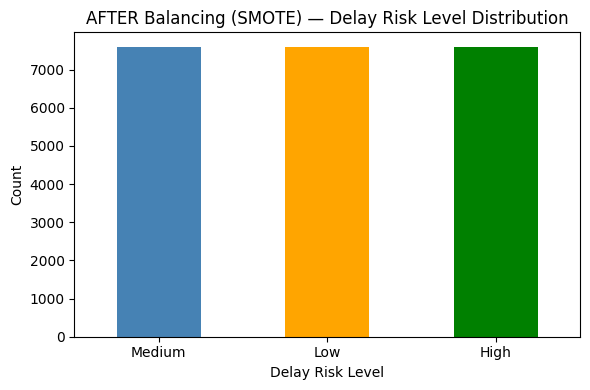

In [21]:
# Bar chart
plt.figure(figsize=(6, 4))
pd.Series(y_train_balanced).value_counts().plot(kind="bar", color=["steelblue","orange","green"])
plt.title("AFTER Balancing (SMOTE) — Delay Risk Level Distribution")
plt.xlabel("Delay Risk Level"); plt.ylabel("Count")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()



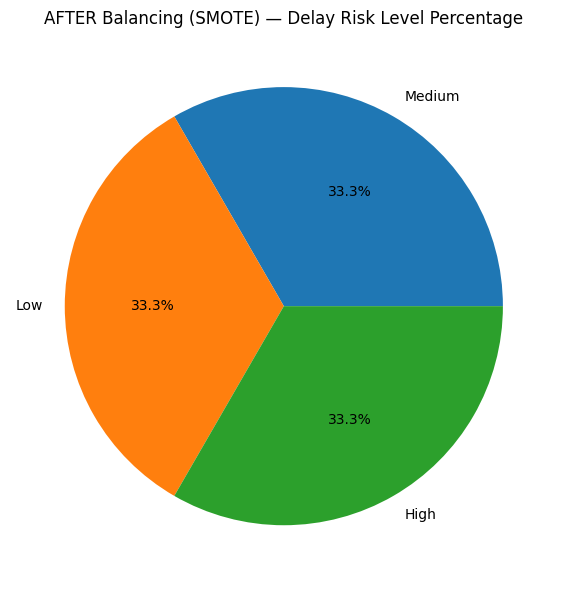

In [22]:
# Pie chart
plt.figure(figsize=(6, 6))
pd.Series(y_train_balanced).value_counts().plot(kind="pie", autopct="%1.1f%%")
plt.title("AFTER Balancing (SMOTE) — Delay Risk Level Percentage")
plt.ylabel(""); plt.tight_layout(); plt.show()



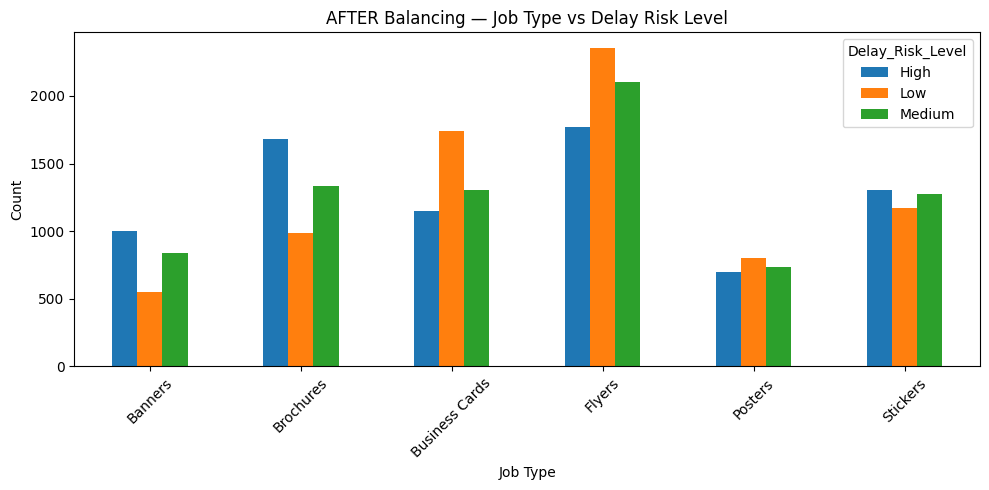

In [24]:
# Job Type crosstab
job_type_cols = [c for c in feature_names if c.startswith("Job_Type_")]
if job_type_cols:
    df_balanced["Job_Type"] = df_balanced[job_type_cols].idxmax(axis=1).str.replace("Job_Type_", "")
    pd.crosstab(df_balanced["Job_Type"], df_balanced["Delay_Risk_Level"]).plot(kind="bar", figsize=(10, 5))
    plt.title("AFTER Balancing — Job Type vs Delay Risk Level")
    plt.xlabel("Job Type"); plt.ylabel("Count")
    plt.xticks(rotation=45); plt.tight_layout(); plt.show()


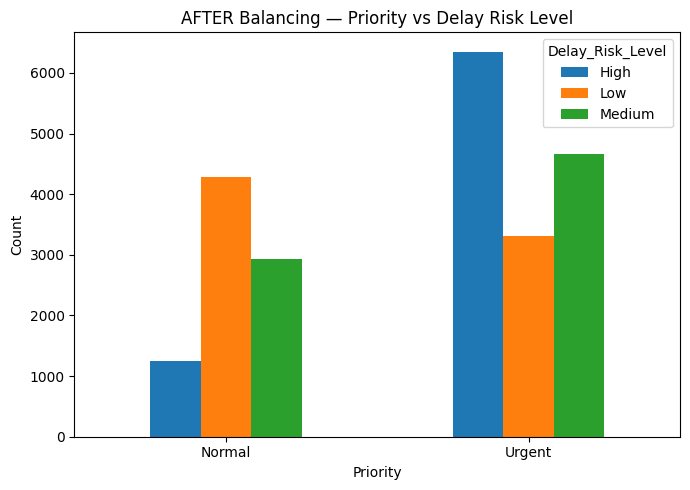

In [25]:

# Priority crosstab
priority_cols = [c for c in feature_names if c.startswith("Priority_")]
if priority_cols:
    df_balanced["Priority"] = df_balanced[priority_cols].idxmax(axis=1).str.replace("Priority_", "")
    pd.crosstab(df_balanced["Priority"], df_balanced["Delay_Risk_Level"]).plot(kind="bar", figsize=(7, 5))
    plt.title("AFTER Balancing — Priority vs Delay Risk Level")
    plt.xlabel("Priority"); plt.ylabel("Count")
    plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# Train 3 Models on Balanced Data

## Logistic Regression Model

In [12]:
lr_model = LogisticRegression(max_iter=2000, class_weight="balanced", random_state=SEED)
lr_model.fit(X_train_balanced, y_train_balanced)
y_pred_lr = lr_model.predict(X_test_processed)

lr_accuracy = accuracy_score(y_test, y_pred_lr)
lr_f1       = f1_score(y_test, y_pred_lr, average="weighted")

print("Logistic Regression Evaluation")
print("Accuracy:", round(lr_accuracy, 4))
print("Weighted F1 Score:", round(lr_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Evaluation
Accuracy: 0.7884
Weighted F1 Score: 0.787

Classification Report:
              precision    recall  f1-score   support

        High       0.79      0.84      0.81      1899
         Low       0.80      0.83      0.81      1884
      Medium       0.78      0.70      0.74      1892

    accuracy                           0.79      5675
   macro avg       0.79      0.79      0.79      5675
weighted avg       0.79      0.79      0.79      5675



## Random Forest Model

In [13]:
rf_model = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    min_samples_leaf=1,
    class_weight="balanced",
    random_state=SEED,
    n_jobs=-1
)
rf_model.fit(X_train_balanced, y_train_balanced)
y_pred_rf = rf_model.predict(X_test_processed)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_f1       = f1_score(y_test, y_pred_rf, average="weighted")

print("Random Forest Evaluation")
print("Accuracy:", round(rf_accuracy, 4))
print("Weighted F1 Score:", round(rf_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Evaluation
Accuracy: 0.8196
Weighted F1 Score: 0.8195

Classification Report:
              precision    recall  f1-score   support

        High       0.82      0.81      0.81      1899
         Low       0.83      0.81      0.82      1884
      Medium       0.81      0.84      0.83      1892

    accuracy                           0.82      5675
   macro avg       0.82      0.82      0.82      5675
weighted avg       0.82      0.82      0.82      5675



## XGBoost Model (Tuned with RandomizedSearchCV)

In [14]:
label_encoder   = LabelEncoder()
y_train_bal_enc = label_encoder.fit_transform(y_train_balanced)
y_test_encoded  = label_encoder.transform(y_test)
num_classes     = len(label_encoder.classes_)

xgb_base = XGBClassifier(
    objective="multi:softprob",
    num_class=num_classes,
    eval_metric="mlogloss",
    random_state=SEED,
    tree_method="hist",
    n_jobs=-1
)

param_grid = {
    "n_estimators":     [300, 500, 700],
    "max_depth":        [4, 5, 6, 7],
    "learning_rate":    [0.03, 0.05, 0.1],
    "subsample":        [0.7, 0.8, 0.9],
    "colsample_bytree": [0.7, 0.8, 0.9],
    "gamma":            [0, 0.1, 0.2],
    "reg_alpha":        [0, 0.01, 0.1],
    "reg_lambda":       [1, 1.5, 2]
}

xgb_search = RandomizedSearchCV(
    estimator=xgb_base,
    param_distributions=param_grid,
    n_iter=30,
    scoring="f1_weighted",
    cv=3,
    verbose=2,
    random_state=SEED,
    n_jobs=-1
)

xgb_search.fit(X_train_balanced, y_train_bal_enc)
best_xgboost_model = xgb_search.best_estimator_

y_pred_xgb_enc = best_xgboost_model.predict(X_test_processed)
y_pred_xgb     = label_encoder.inverse_transform(y_pred_xgb_enc)

xgb_accuracy = accuracy_score(y_test, y_pred_xgb)
xgb_f1       = f1_score(y_test, y_pred_xgb, average="weighted")

print("Best XGBoost Parameters:")
print(xgb_search.best_params_)
print("\nTuned XGBoost Evaluation")
print("Accuracy:", round(xgb_accuracy, 4))
print("Weighted F1 Score:", round(xgb_f1, 4))
print("\nClassification Report:")
print(classification_report(y_test, y_pred_xgb))

Fitting 3 folds for each of 30 candidates, totalling 90 fits
Best XGBoost Parameters:
{'subsample': 0.9, 'reg_lambda': 2, 'reg_alpha': 0, 'n_estimators': 300, 'max_depth': 5, 'learning_rate': 0.03, 'gamma': 0, 'colsample_bytree': 0.8}

Tuned XGBoost Evaluation
Accuracy: 0.8631
Weighted F1 Score: 0.8631

Classification Report:
              precision    recall  f1-score   support

        High       0.86      0.87      0.86      1899
         Low       0.86      0.87      0.86      1884
      Medium       0.87      0.86      0.86      1892

    accuracy                           0.86      5675
   macro avg       0.86      0.86      0.86      5675
weighted avg       0.86      0.86      0.86      5675



# Confusion Matrix

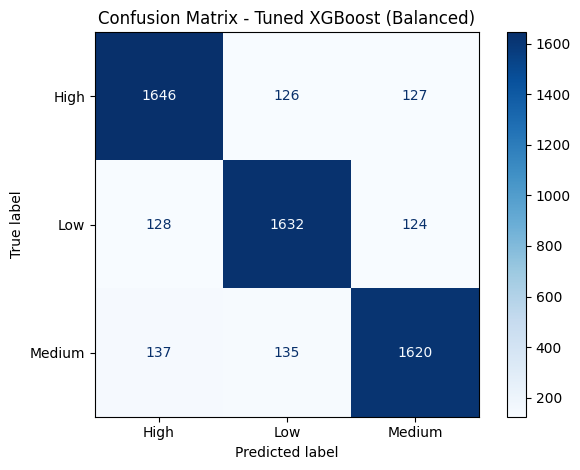

In [15]:
cm   = confusion_matrix(y_test, y_pred_xgb)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=label_encoder.classes_)
disp.plot(cmap="Blues")
plt.title("Confusion Matrix - Tuned XGBoost (Balanced)")
plt.tight_layout()
plt.show()

# Model Comparison Table

In [16]:
model_results = pd.DataFrame({
    "Model":            ["Logistic Regression", "Random Forest", "XGBoost"],
    "Accuracy":         [lr_accuracy, rf_accuracy, xgb_accuracy],
    "Weighted F1 Score":[lr_f1,       rf_f1,       xgb_f1]
})
model_results = model_results.sort_values(by="Weighted F1 Score", ascending=False)
display(model_results)

,Model,Accuracy,Weighted F1 Score
2,XGBoost,0.863084,0.863078
1,Random Forest,0.819559,0.819516
0,Logistic Regression,0.788370,0.787034


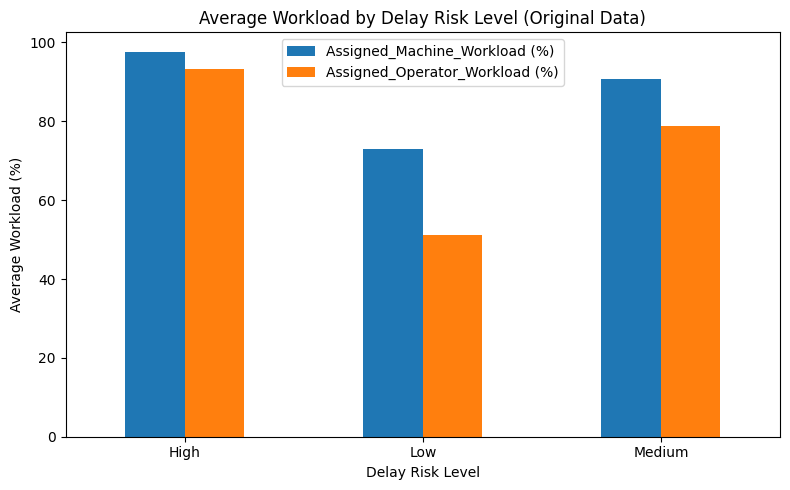

In [17]:
workload_avg = df.groupby("Delay_Risk_Level")[
    ["Assigned_Machine_Workload (%)", "Assigned_Operator_Workload (%)"]
].mean()

workload_avg.plot(kind="bar", figsize=(8, 5))
plt.title("Average Workload by Delay Risk Level (Original Data)")
plt.xlabel("Delay Risk Level"); plt.ylabel("Average Workload (%)")
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

# 📈 Feature Importance — Top 20

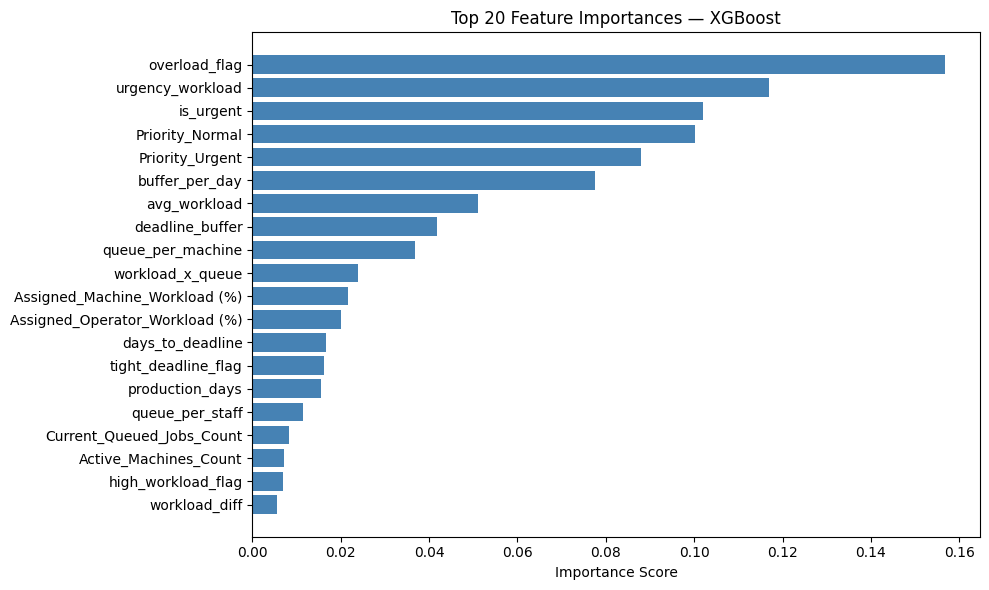

In [18]:
feature_names_all = (
    numeric_features
    + list(preprocessor.named_transformers_["cat"]["onehot"].get_feature_names_out(categorical_features))
)

importances = best_xgboost_model.feature_importances_
top_idx     = np.argsort(importances)[::-1][:20]

plt.figure(figsize=(10, 6))
plt.barh(
    [feature_names_all[i] for i in top_idx][::-1],
    importances[top_idx][::-1],
    color="steelblue"
)
plt.title("Top 20 Feature Importances — XGBoost")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

# Save Tuned XGBoost Model

In [19]:
os.makedirs("saved_model", exist_ok=True)

joblib.dump(best_xgboost_model, "saved_model/best_xgboost_delay_model.pkl")
joblib.dump(label_encoder,      "saved_model/label_encoder.pkl")
joblib.dump(fe,                 "saved_model/feature_engineer.pkl")
joblib.dump(preprocessor,       "saved_model/preprocessor.pkl")

metadata = {
    "model_name":        "Tuned XGBoost (SMOTE Balanced, Relabeled Data)",
    "accuracy":          xgb_accuracy,
    "weighted_f1_score": xgb_f1,
    "classes":           list(label_encoder.classes_),
    "best_parameters":   xgb_search.best_params_,
    "input_columns":     list(X.columns)
}

with open("saved_model/xgboost_model_metadata.json", "w") as f:
    json.dump(metadata, f, indent=4)

print("Model saved successfully!")
print(f"Final Accuracy: {xgb_accuracy:.4f}")
print(f"Final F1 Score: {xgb_f1:.4f}")

Model saved successfully!
Final Accuracy: 0.8631
Final F1 Score: 0.8631


# Test Saved Model

In [20]:
loaded_model = joblib.load("saved_model/best_xgboost_delay_model.pkl")
loaded_le    = joblib.load("saved_model/label_encoder.pkl")
loaded_fe    = joblib.load("saved_model/feature_engineer.pkl")
loaded_prep  = joblib.load("saved_model/preprocessor.pkl")

sample = pd.DataFrame([{
    "Job_Type": "Brochures",
    "Quantity": 500,
    "Color_Type (BW / Full Color)": "Full Color",
    "Material_Type": "Glossy Paper",
    "Order_Request_Date": "2025-04-01",
    "Requested_Deadline_Date": "2025-04-04",
    "Current_Queued_Jobs_Count": 80,
    "Active_Machines_Count": 4,
    "Total_Machines_Count": 6,
    "Available_Staff_Count": 3,
    "Total_Staff_Count": 8,
    "Priority": "Urgent",
    "Assigned_Date": "2025-04-02",
    "Estimated_End_Date": "2025-04-05",
    "Assigned_Machine_Workload (%)": 85,
    "Assigned_Operator_Workload (%)": 90
}])

sample_fe   = loaded_fe.transform(sample)
sample_proc = loaded_prep.transform(sample_fe)

pred_encoded = loaded_model.predict(sample_proc)
pred_label   = loaded_le.inverse_transform(pred_encoded)
probability  = loaded_model.predict_proba(sample_proc)

print("Predicted Delay Risk:", pred_label[0])
print("\nClass Probabilities:")
for cls, prob in zip(loaded_le.classes_, probability[0]):
    print(f"  {cls}: {prob:.4f}")

Predicted Delay Risk: Medium

Class Probabilities:
  High: 0.0782
  Low: 0.0879
  Medium: 0.8339
